<div dir="rtl" style="text-align: left;">

# Prompts, חלק 1-הקדמה : שמות הסטודנטים, תיאור הבעיה והנתונים

* **שמות הסטודנטים:** (2371)מוחמד אלעיסאוי
* **תיאור הבעיה:** פרויקט זה עוסק בסיווג הודעות טקסט להודעות לגיטימיות (Ham) ולהודעות זבל (Spam) באמצעות מודל למידת מכונה שנבנה מאפס. מסווגות הודעות SMS.
* **הנתונים:** דאטה-סט המכיל הודעות.
* **Prompts (שימוש ב-AI):** נעזרתי במודל Gemini להבנת המתמטיקה של מודל Naive Bayes לאימון מוכנות ללא ספריות וסידור התעויות בקוד נעשו על ידינו אך בניית האלגוריתמים ולעיצוב הגרפים.

</div>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. טעינת הנתונים (Load Data)
df = pd.read_csv('./datasets/spam.csv')

# 2. המרת התוויות למספרים (Mapping Labels)
df['label'] = df['label'].astype(str).str.lower().map({
    'ham': 0, 'spam': 1
}).astype(int)

# 3. חלוקה אקראית (Train/Test Split 80/20)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
split_index = int(0.8 * len(df_shuffled))

train_df = df_shuffled.iloc[:split_index].copy()
test_df = df_shuffled.iloc[split_index:].copy()

print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}\n")

print("--- דוגמה מהנתונים (First 5 rows) ---")
display(train_df.head(5))

Train set size: 4457
Test set size: 1115

--- דוגמה מהנתונים (First 5 rows) ---


,label,email_text
0,0,Squeeeeeze!! This is christmas hug.. If u lik ...
1,0,And also I've sorta blown him off a couple tim...
2,0,Mmm thats better now i got a roast down me! i...
3,0,Mm have some kanji dont eat anything heavy ok
4,0,So there's a ring that comes with the guys cos...


<div dir="rtl" style="text-align: left;">

# חלק 2 – הכנת הנתונים (Feature Engineering)
* בשלב זה נבצע ניקוי בסיסי לטקסט (הסרת סימני פיסוק ואותיות קטנות). לאחר מכן נשתמש ב-`CountVectorizer` וב-Stop-words של `nltk` כדי לחלץ את המאפיינים (Bag of Words).
</div>

In [8]:
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords', quiet=True)

# 1. פונקציה לניקוי הטקסט
def preprocess_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

train_df['Clean_Text'] = train_df['email_text'].apply(preprocess_text)
test_df['Clean_Text'] = test_df['email_text'].apply(preprocess_text)

# 2. חילוץ מאפיינים (Feature Extraction)
stop_words_list = stopwords.words('english')
vectorizer = CountVectorizer(stop_words=stop_words_list)

X_train_counts = vectorizer.fit_transform(train_df['Clean_Text']).toarray()
y_train = train_df['label'].values

X_test_counts = vectorizer.transform(test_df['Clean_Text']).toarray()
y_test = test_df['label'].values

print(f"גודל המילון (Vocabulary Size): {len(vectorizer.vocabulary_)} מילים.")

print("\n--- הדגמה על 3 דוגמאות (Feature Engineering Flow) ---")
for i in range(3):
    original = train_df['email_text'].iloc[i]
    cleaned = train_df['Clean_Text'].iloc[i]
    vector_snip = X_train_counts[i][:15]
    
    print(f"\n[דוגמה {i+1}]")
    print(f"טקסט מקורי: {original[:60]}...")
    print(f"טקסט נקי: {cleaned[:60]}...")
    print(f"וקטור מספרי (חלקי): {vector_snip}...")

גודל המילון (Vocabulary Size): 8305 מילים.

--- הדגמה על 3 דוגמאות (Feature Engineering Flow) ---

[דוגמה 1]
טקסט מקורי: Squeeeeeze!! This is christmas hug.. If u lik my frndshp den...
טקסט נקי: squeeeeeze this is christmas hug if u lik my frndshp den hug...
וקטור מספרי (חלקי): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]...

[דוגמה 2]
טקסט מקורי: And also I've sorta blown him off a couple times recently so...
טקסט נקי: and also ive sorta blown him off a couple times recently so ...
וקטור מספרי (חלקי): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]...

[דוגמה 3]
טקסט מקורי: Mmm thats better now i got a roast down me! id b better if ...
טקסט נקי: mmm thats better now i got a roast down me id b better if i...
וקטור מספרי (חלקי): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]...


<div dir="rtl" style="text-align: left;">

# חלק 3 - פירוט על מימוש אלגוריתם ה-Naive Bayes
* בנינו מחלקה מאפס (From Scratch) שמממשת את האלגוריתם בעזרת `numpy` כדי להבטיח ריצה מהירה. 
* השתמשנו ב-**Log Probabilities** כדי למנוע קריסה של מספרים קטנים (Underflow), והוספנו פרמטר החלקה **Laplace Smoothing (Alpha)**.
</div>

In [9]:
class CustomNaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha 
        self.classes_ = None
        self.class_log_prior_ = None
        self.feature_log_prob_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        self.class_log_prior_ = np.zeros(n_classes)
        self.feature_log_prob_ = np.zeros((n_classes, n_features))
        
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            
            # Prior probability (Log)
            self.class_log_prior_[idx] = np.log(X_c.shape[0] / n_samples)
            
            # Conditional probability (Log) with Laplace Smoothing
            count_c = np.sum(X_c, axis=0)
            self.feature_log_prob_[idx] = np.log(
                (count_c + self.alpha) / (np.sum(count_c) + self.alpha * n_features)
            )

    def predict(self, X):
        # Matrix multiplication for fast prediction
        log_posteriors = X @ self.feature_log_prob_.T + self.class_log_prior_
        return self.classes_[np.argmax(log_posteriors, axis=1)]

print("האלגוריתם נטען בהצלחה (Custom Naive Bayes Ready).")

האלגוריתם נטען בהצלחה (Custom Naive Bayes Ready).


<div dir="rtl" style="text-align: left;">

# חלק 4 – הפעלת המודל (Model Execution)

* הפעלת מודל הבסיס שלנו (Baseline) עם ערך אלפא דיפולטיבי (1.0) על הנתונים הרגילים.
</div>

In [10]:
# אימון מודל הבסיס
baseline_model = CustomNaiveBayes(alpha=1.0)
baseline_model.fit(X_train_counts, y_train)

print("המודל אומן בהצלחה על נתוני האימון.")

המודל אומן בהצלחה על נתוני האימון.


In [11]:
from sklearn.metrics import classification_report

# חיזוי
y_pred_baseline = baseline_model.predict(X_test_counts)

print("--- דוח סיווג למודל הבסיס (Baseline Report) ---")
print(classification_report(y_test, y_pred_baseline, target_names=['Ham (0)', 'Spam (1)']))

--- דוח סיווג למודל הבסיס (Baseline Report) ---
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.99       961
    Spam (1)       0.97      0.90      0.93       154

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



<div dir="rtl" style="text-align: left;">

# חלק 5 (בונוס) : ניהול ניסויים עם Grid Search ו-Cross Validation / טיפול בנתונים לא מאוזנים (Imbalanced Data) / בדיקת איכות מיוחדת, Explainability (הבנת התוצאות), סיכום והצגת תוצאות הניסויים

בחלק זה נבצע "שדרוג" כולל למערכת:
1. **Imbalanced Data:** נאזן את נתוני האימון באמצעות Oversampling.
2. **Grid Search & 5-Fold CV:** נחפש את הערך האופטימלי ל-Alpha על הנתונים המאוזנים בלבד, ללא הדלפת נתונים.
3. **Explainability:** נבדוק אילו מילים הכי משפיעות על הסיווג כדי "להבין" את המודל.
4. **סיכום:** נציג את תוצאות המודל הסופי.
</div>

--- מתחיל Grid Search 5-Fold CV על הנתונים המאוזנים ---
Alpha: 0.1 | CV Macro F1: 0.9913
Alpha: 0.5 | CV Macro F1: 0.9912
Alpha: 1.0 | CV Macro F1: 0.9891
Alpha: 2.0 | CV Macro F1: 0.9842
Alpha: 5.0 | CV Macro F1: 0.9764
🏆 Alpha המנצח: 0.1

--- Explainability: המילים המובילות לכל מחלקה ---
Ham Top Words: im, ltgt, get, ur, ok, dont, go, know, got, ill
Spam Top Words: call, free, txt, ur, claim, stop, text, mobile, prize, reply

--- סיכום: דוח סיווג למודל הסופי (Final Report) ---
              precision    recall  f1-score   support

     Ham (0)       0.99      0.98      0.98       961
    Spam (1)       0.86      0.92      0.89       154

    accuracy                           0.97      1115
   macro avg       0.92      0.95      0.93      1115
weighted avg       0.97      0.97      0.97      1115



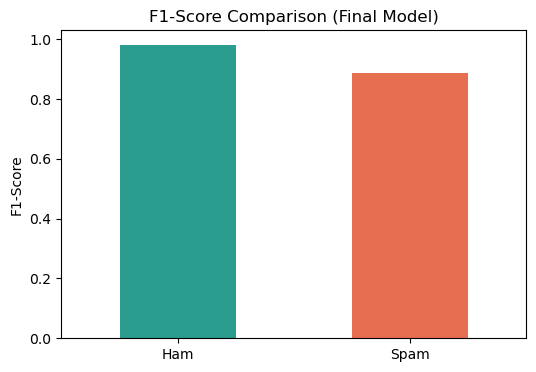

In [12]:
from sklearn.metrics import f1_score

# ========================================================
# 1. טיפול בנתונים לא מאוזנים (Imbalanced Data - Oversampling)
# ========================================================
target_size = train_df['label'].value_counts().max()
balanced_data_list = []

for class_label, group in train_df.groupby('label'):
    resampled_group = group.sample(target_size, replace=True, random_state=42)
    balanced_data_list.append(resampled_group)

train_df_balanced = pd.concat(balanced_data_list).sample(frac=1, random_state=42).reset_index(drop=True)

# בניית מטריצות חדשות מהנתונים המאוזנים
vectorizer_balanced = CountVectorizer(stop_words=stop_words_list)
X_train_bal = vectorizer_balanced.fit_transform(train_df_balanced['Clean_Text']).toarray()
y_train_bal = train_df_balanced['label'].values
X_test_bal = vectorizer_balanced.transform(test_df['Clean_Text']).toarray() # הבדיקה נשארת כפי שהיא

# ========================================================
# 2. ניהול ניסויים עם Grid Search ו-Cross Validation (5-Fold)
# ========================================================
def custom_cv_alpha(X, y, alpha, k=5):
    fold_size = X.shape[0] // k
    scores = []
    indices = np.arange(X.shape[0])
    for i in range(k):
        val_idx = indices[i * fold_size : (i + 1) * fold_size]
        train_idx = np.concatenate([indices[:i * fold_size], indices[(i + 1) * fold_size:]])
        
        temp_model = CustomNaiveBayes(alpha=alpha)
        temp_model.fit(X[train_idx], y[train_idx])
        
        preds = temp_model.predict(X[val_idx])
        scores.append(f1_score(y[val_idx], preds, average='macro'))
    return np.mean(scores)

alpha_options = [0.1, 0.5, 1.0, 2.0, 5.0]
cv_results = []
print("--- מתחיל Grid Search 5-Fold CV על הנתונים המאוזנים ---")
for a in alpha_options:
    score = custom_cv_alpha(X_train_bal, y_train_bal, alpha=a)
    cv_results.append({'Alpha': a, 'Macro_F1': score})
    print(f"Alpha: {a} | CV Macro F1: {score:.4f}")

best_alpha = pd.DataFrame(cv_results).loc[pd.DataFrame(cv_results)['Macro_F1'].idxmax()]['Alpha']
print(f"🏆 Alpha המנצח: {best_alpha}")

# ========================================================
# 3. בדיקת איכות מיוחדת, Explainability (הבנת התוצאות)
# ========================================================
final_model = CustomNaiveBayes(alpha=best_alpha)
final_model.fit(X_train_bal, y_train_bal)
y_pred_final = final_model.predict(X_test_bal)

print("\n--- Explainability: המילים המובילות לכל מחלקה ---")
feature_names = vectorizer_balanced.get_feature_names_out()
for i, label in enumerate(['Ham', 'Spam']):
    top_indices = np.argsort(final_model.feature_log_prob_[i])[::-1][:10]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"{label} Top Words: {', '.join(top_words)}")

# ========================================================
# 4. סיכום והצגת תוצאות הניסויים (Experiment Summary)
# ========================================================
print("\n--- סיכום: דוח סיווג למודל הסופי (Final Report) ---")
print(classification_report(y_test, y_pred_final, target_names=['Ham (0)', 'Spam (1)']))

# הצגה ויזואלית של האיכות
report_dict = classification_report(y_test, y_pred_final, target_names=['Ham', 'Spam'], output_dict=True)
plt.figure(figsize=(6, 4))
pd.DataFrame(report_dict).transpose().iloc[:-3]['f1-score'].plot(kind='bar', color=['#2a9d8f', '#e76f51'])
plt.title('F1-Score Comparison (Final Model)')
plt.ylabel('F1-Score')
plt.xticks(rotation=0)
plt.show()